In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/salesdaily.csv')

df['datum'] = pd.to_datetime(df['datum'])

df.head()



,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,2014-01-05,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,2014-01-06,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [6]:
atc_cols=['M01AB','M01AE','N02BA','N02BE','N05B','R03','R06']

ventas_totales = df[atc_cols].sum().sort_values(ascending =False)

promedio_diario = df[atc_cols].mean().sort_values(ascending = False)

print("--- RESULTADOS DE VENTAS")
print(f"La categoria que mas  vende  en total es: {ventas_totales.idxmax()} ")
print(f"La categoria con mayor promedio diario es :{promedio_diario.idxmax()}")



--- RESULTADOS DE VENTAS
La categoria que mas  vende  en total es: N02BE 
La categoria con mayor promedio diario es :N02BE


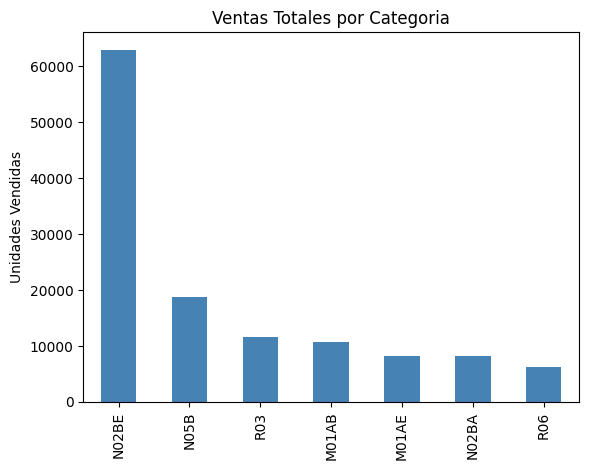

In [9]:
ventas_totales.plot(kind='bar', color='steelblue', title = 'Ventas Totales por Categoria')
plt.ylabel('Unidades Vendidas')
plt.show()

In [10]:
atc_cols=['M01AB','M01AE','N02BA','N02BE','N05B','R03','R06']

def obtener_top_3(anio , mes) :
    filtro = df[(df['datum'].dt.year == anio) & (df['datum'].dt.month == mes)]
    return filtro[atc_cols].sum().sort_values(ascending=False).head(3)
print("--- ANALIZANDO MESES ESPECIFICOS ---")
print("Top 3 - Enero 2015 : \n", obtener_top_3(2015,1))
print("\nTop 3 - Julio 2016 : \n" , obtener_top_3(2016, 7))
print("\nTop 3 - Septiembre 2017 : \n", obtener_top_3(2017 , 9))

--- ANALIZANDO MESES ESPECIFICOS ---
Top 3 - Enero 2015 : 
 N02BE    1044.24
N05B      463.00
R03       177.25
dtype: float64

Top 3 - Julio 2016 : 
 N02BE    652.362000
N05B     240.000000
M01AB    194.528333
dtype: float64

Top 3 - Septiembre 2017 : 
 N02BE    863.75
N05B     223.00
R03      139.00
dtype: float64


In [11]:
ventas_2017 = df[df['datum'].dt.year == 2017 ][atc_cols].sum()
print(f"\n{ventas_2017.idxmax()} con {ventas_2017.max()} unidades.\n")
df['mes'] = df['datum'].dt.month
respiratorios_tendencia = df.groupby('mes') ['R03'].mean()


N02BE con 9258.80483333 unidades.



In [ ]:
plt.figure(figsize=(10 , 5))
respiratorios_tendencia.plot(kind='line', marker='o' ,color= 'red', linewidth=2)
plt.title('Tendencia Mensual de Medicamentos Respiratorios (R03)')
plt.xlabel('Mes(1=Enero , 12=Diciembre)')
plt.ylabel('Promedio de Ventas Diarias')
plt.xticks(range(1 , 13))
plt.grid(True ,)